*Nota: para o funcionamento adequado do código é necessário fazer o upload dos arquivos winequality-red.csv e winequality-white.csv. Atente-se ao caminho dos arquivos.*

#Bibliotecas Utilizadas

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew
import matplotlib.pyplot as plt

#Item 1


In [ ]:
"""
A lógica do item 1 é a seguinte:
  1. Carregar os datasets
  2. Pegar a lista de preditores (colunas, excluindo 'quality')
  3. Obter o número de observações N
  4. Obter o número de variáveis preditivas D
  5. Obter o número de classes distintas L
  6. Obter distribuição de classes

"""

In [ ]:
def getListaPreditor(dataframe):
  return dataframe.columns.drop('quality')

In [ ]:
def getNumObs(dataframe):
  return len(dataframe)


In [ ]:
def getNumPreditor(dataframe):
  lista_preditores = getListaPreditor(dataframe)

  return len(lista_preditores)

In [ ]:
def getNumClass(dataframe):
  # unique() devolve um array só com os valores distintos e contamos com len()
  return len(dataframe['quality'].unique())

In [ ]:
def getDistClass(dataframe):
  return dataframe['quality'].value_counts()

In [ ]:
# 1.1 - carregando os datasets
df_red = pd.read_csv('/content/winequality-red.csv', sep=';') # Atente-se ao caminho correto dos arquivos
df_white = pd.read_csv('/content/winequality-white.csv', sep=';')


In [ ]:
# 1.2 - Lista de preditores
preditores = getListaPreditor(df_red) # 'drop' exclui a coluna 'quality'
print(preditores)

In [ ]:
# 1.3 - Numero de observações
n_red = getNumObs(df_red)
n_white = getNumObs(df_white)

print(f"Número de observações:\nVinho Vermelho: {n_red}\nVinho Branco: {n_white}")

In [ ]:
# 1.4 - Número de preditores
d_red = getNumPreditor(df_red)
d_white = getNumPreditor(df_white)

print(f"Número de preditores:\nVinho Vermelho: {d_red}\nVinho Branco: {d_white}")

In [ ]:
# 1.5 - Número de classes
l_red = getNumClass(df_red)
l_white = getNumClass(df_white)

print(f"Número de classes:\nVinho Vermelho: {l_red}\nVinho Branco: {l_white}")

In [ ]:
# 1.6 - Distribuição de classes
cd_dfred = getDistClass(df_red)
cd_dfwhite = getDistClass(df_white)

In [ ]:
cd_dfred

In [ ]:
cd_dfwhite

# Item 2

In [ ]:
"""
A Lógica do item 2 será a seguinte:
  1. Laço para calcular a média, std e skewness de cada preditor
  2. Montar uma tabela
  3. Boxplots e histogramas
"""

In [ ]:

def histPlot(lista_preditores, dataframe):
  figs, axs = plt.subplots(nrows=2, ncols=2) # Criar figura com 2x2 subplots

  for indice, coluna in enumerate(lista_preditores):
    valores = dataframe[coluna]
    i = indice // 2 # indice//n. de colunas = n. da linha
    j = indice % 2 # indice % n. de colunas = n. da coluna

    axs[i, j].set_title(coluna)
    axs[i, j].hist(valores)

  plt.tight_layout() # Ajusta o layout para nada ficar "espremido"


In [ ]:
def boxPlot(lista_preditores, dataframe):
  figs, axs = plt.subplots(nrows=2, ncols=2) # Criar figura com 2x2 subplots

  for indice, coluna in enumerate(lista_preditores):
    valores = dataframe[coluna]
    i = indice // 2 # indice//n. de colunas = n. da linha
    j = indice % 2 # indice % n. de colunas = n. da coluna

    axs[i, j].set_title(coluna)
    axs[i, j].boxplot(valores)

  plt.tight_layout() # Ajusta o layout para nada ficar "espremido"


In [ ]:


def calcularMetricas(dataframe):

  resultados = {} # Vamos armazenar os resultados em um dicionário de dicionários

  for coluna in preditores:
    valores = dataframe[coluna]

    media = np.mean(valores)
    std = np.std(valores)
    skewness = skew(valores)

    # Adicionando os resultados ao dicionário acima
    resultados[coluna] = {'media': media, 'std':std, 'skewness':skewness}

  # 2.4 Montar uma tabela (DataFrame)
  tabela = pd.DataFrame(resultados).T

  return tabela



In [ ]:
# 2.3 - Cálculo das Métricas
tabela_red = calcularMetricas(df_red)
tabela_red

In [ ]:
# 2.5 - Histogramas e Boxplot

histPlot(preditores[0:4], df_red)

In [ ]:
histPlot(preditores[4:8], df_red)

In [ ]:

histPlot(preditores[8:11], df_red)

In [ ]:
boxPlot(preditores[0:4], df_red)

In [ ]:
boxPlot(preditores[4:8], df_red)

In [ ]:
boxPlot(preditores[8:11], df_red)

In [ ]:
# Faremos o mesmo para o DataFrame df_white

tabela_white = calcularMetricas(df_white)
tabela_white

In [ ]:
histPlot(preditores[0:4], df_white)


In [ ]:
histPlot(preditores[4:8], df_white)

In [ ]:
histPlot(preditores[8:11], df_white)

In [ ]:
boxPlot(preditores[0:4], df_white)

In [ ]:
boxPlot(preditores[4:8], df_white)

In [ ]:
boxPlot(preditores[8:11], df_white)

#Item 3


In [ ]:


"""
A lógica do item 3 será a seguinte:
  1. Obter a lista de classes (valores distintos de 'quality')
  2. Laço para calcular a média, std e skewness de cada preditor, para cada classe
  3. Montar uma tabela
  4. Boxplots e histogramas condicionais (um histograma por preditor e por classe)
  5. Poder discriminativo
"""

# 3.1 - Lista de classes
def getListaClasses(dataframe):
  return sorted(dataframe['quality'].unique())


def histPlotCondicional(coluna, dataframe):
  classes = getListaClasses(dataframe)
  ncols = 3
  nrows = int(np.ceil(len(classes) / ncols)) # Linhas necessárias para caber todas as classes

  figs, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows), sharex=True) # sharex: mesma escala em x
  axs = axs.flatten()

  bins = np.histogram_bin_edges(dataframe[coluna], bins=10) # Mesmos bins para todas as classes

  for indice, classe in enumerate(classes):
    valores = dataframe[dataframe['quality'] == classe][coluna] # Apenas as observações da classe

    axs[indice].set_title(f'quality = {classe} (N = {len(valores)})')
    axs[indice].hist(valores, bins=bins)

  figs.suptitle(coluna)
  plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta o layout para nada ficar "espremido"


def boxPlotCondicional(lista_preditores, dataframe):
  classes = getListaClasses(dataframe)
  figs, axs = plt.subplots(nrows=2, ncols=2) # Criar figura com 2x2 subplots

  for indice, coluna in enumerate(lista_preditores):
    # Lista com os valores do preditor de cada classe (um boxplot por classe)
    valores = [dataframe[dataframe['quality'] == classe][coluna] for classe in classes]
    i = indice // 2 # indice//n. de colunas = n. da linha
    j = indice % 2 # indice % n. de colunas = n. da coluna

    axs[i, j].set_title(coluna)
    axs[i, j].boxplot(valores)
    axs[i, j].set_xticklabels(classes)

  plt.tight_layout() # Ajusta o layout para nada ficar "espremido"


def calcularMetricasCondicionais(dataframe):

  classes = getListaClasses(dataframe)
  resultados = {} # Dicionário de dicionários, com chave (preditor, classe)

  for coluna in preditores:
    for classe in classes:
      valores = dataframe[dataframe['quality'] == classe][coluna] # Apenas as observações da classe

      media = np.mean(valores)
      std = np.std(valores)
      skewness = skew(valores)

      resultados[(coluna, classe)] = {'media': media, 'std':std, 'skewness':skewness}

  # 3.3 Montar uma tabela (DataFrame)
  tabela = pd.DataFrame(resultados).T
  tabela.index.names = ['preditor', 'quality']

  return tabela


# 3.5 - Poder discriminativo

# Nenhum dos onze preditores separa, sozinho, as classes de
# qualidade: os box-plots e histogramas condicionais se sobrepõem bastante,
# sobretudo entre as classes 5, 6 e 7, que concentram a maior parte das
# observações. Alguns preditores mostram poder discriminativo parcial, com
# tendência monotônica em relação à qualidade.

In [ ]:
# 3.2 - Cálculo das Métricas Condicionais
tabela_cond_red = calcularMetricasCondicionais(df_red)
tabela_cond_red

In [ ]:
# 3.4 - Histogramas e Boxplot

for coluna in preditores:
  histPlotCondicional(coluna, df_red)


In [ ]:
boxPlotCondicional(preditores[0:4], df_red)

In [ ]:
boxPlotCondicional(preditores[4:8], df_red)

In [ ]:
boxPlotCondicional(preditores[8:11], df_red)

In [ ]:
# Faremos o mesmo para o DataFrame df_white

tabela_cond_white = calcularMetricasCondicionais(df_white)
tabela_cond_white

In [ ]:
for coluna in preditores:
  histPlotCondicional(coluna, df_white)

In [ ]:
boxPlotCondicional(preditores[0:4], df_white)

In [ ]:
boxPlotCondicional(preditores[4:8], df_white)

In [ ]:
boxPlotCondicional(preditores[8:11], df_white)

#Item 4


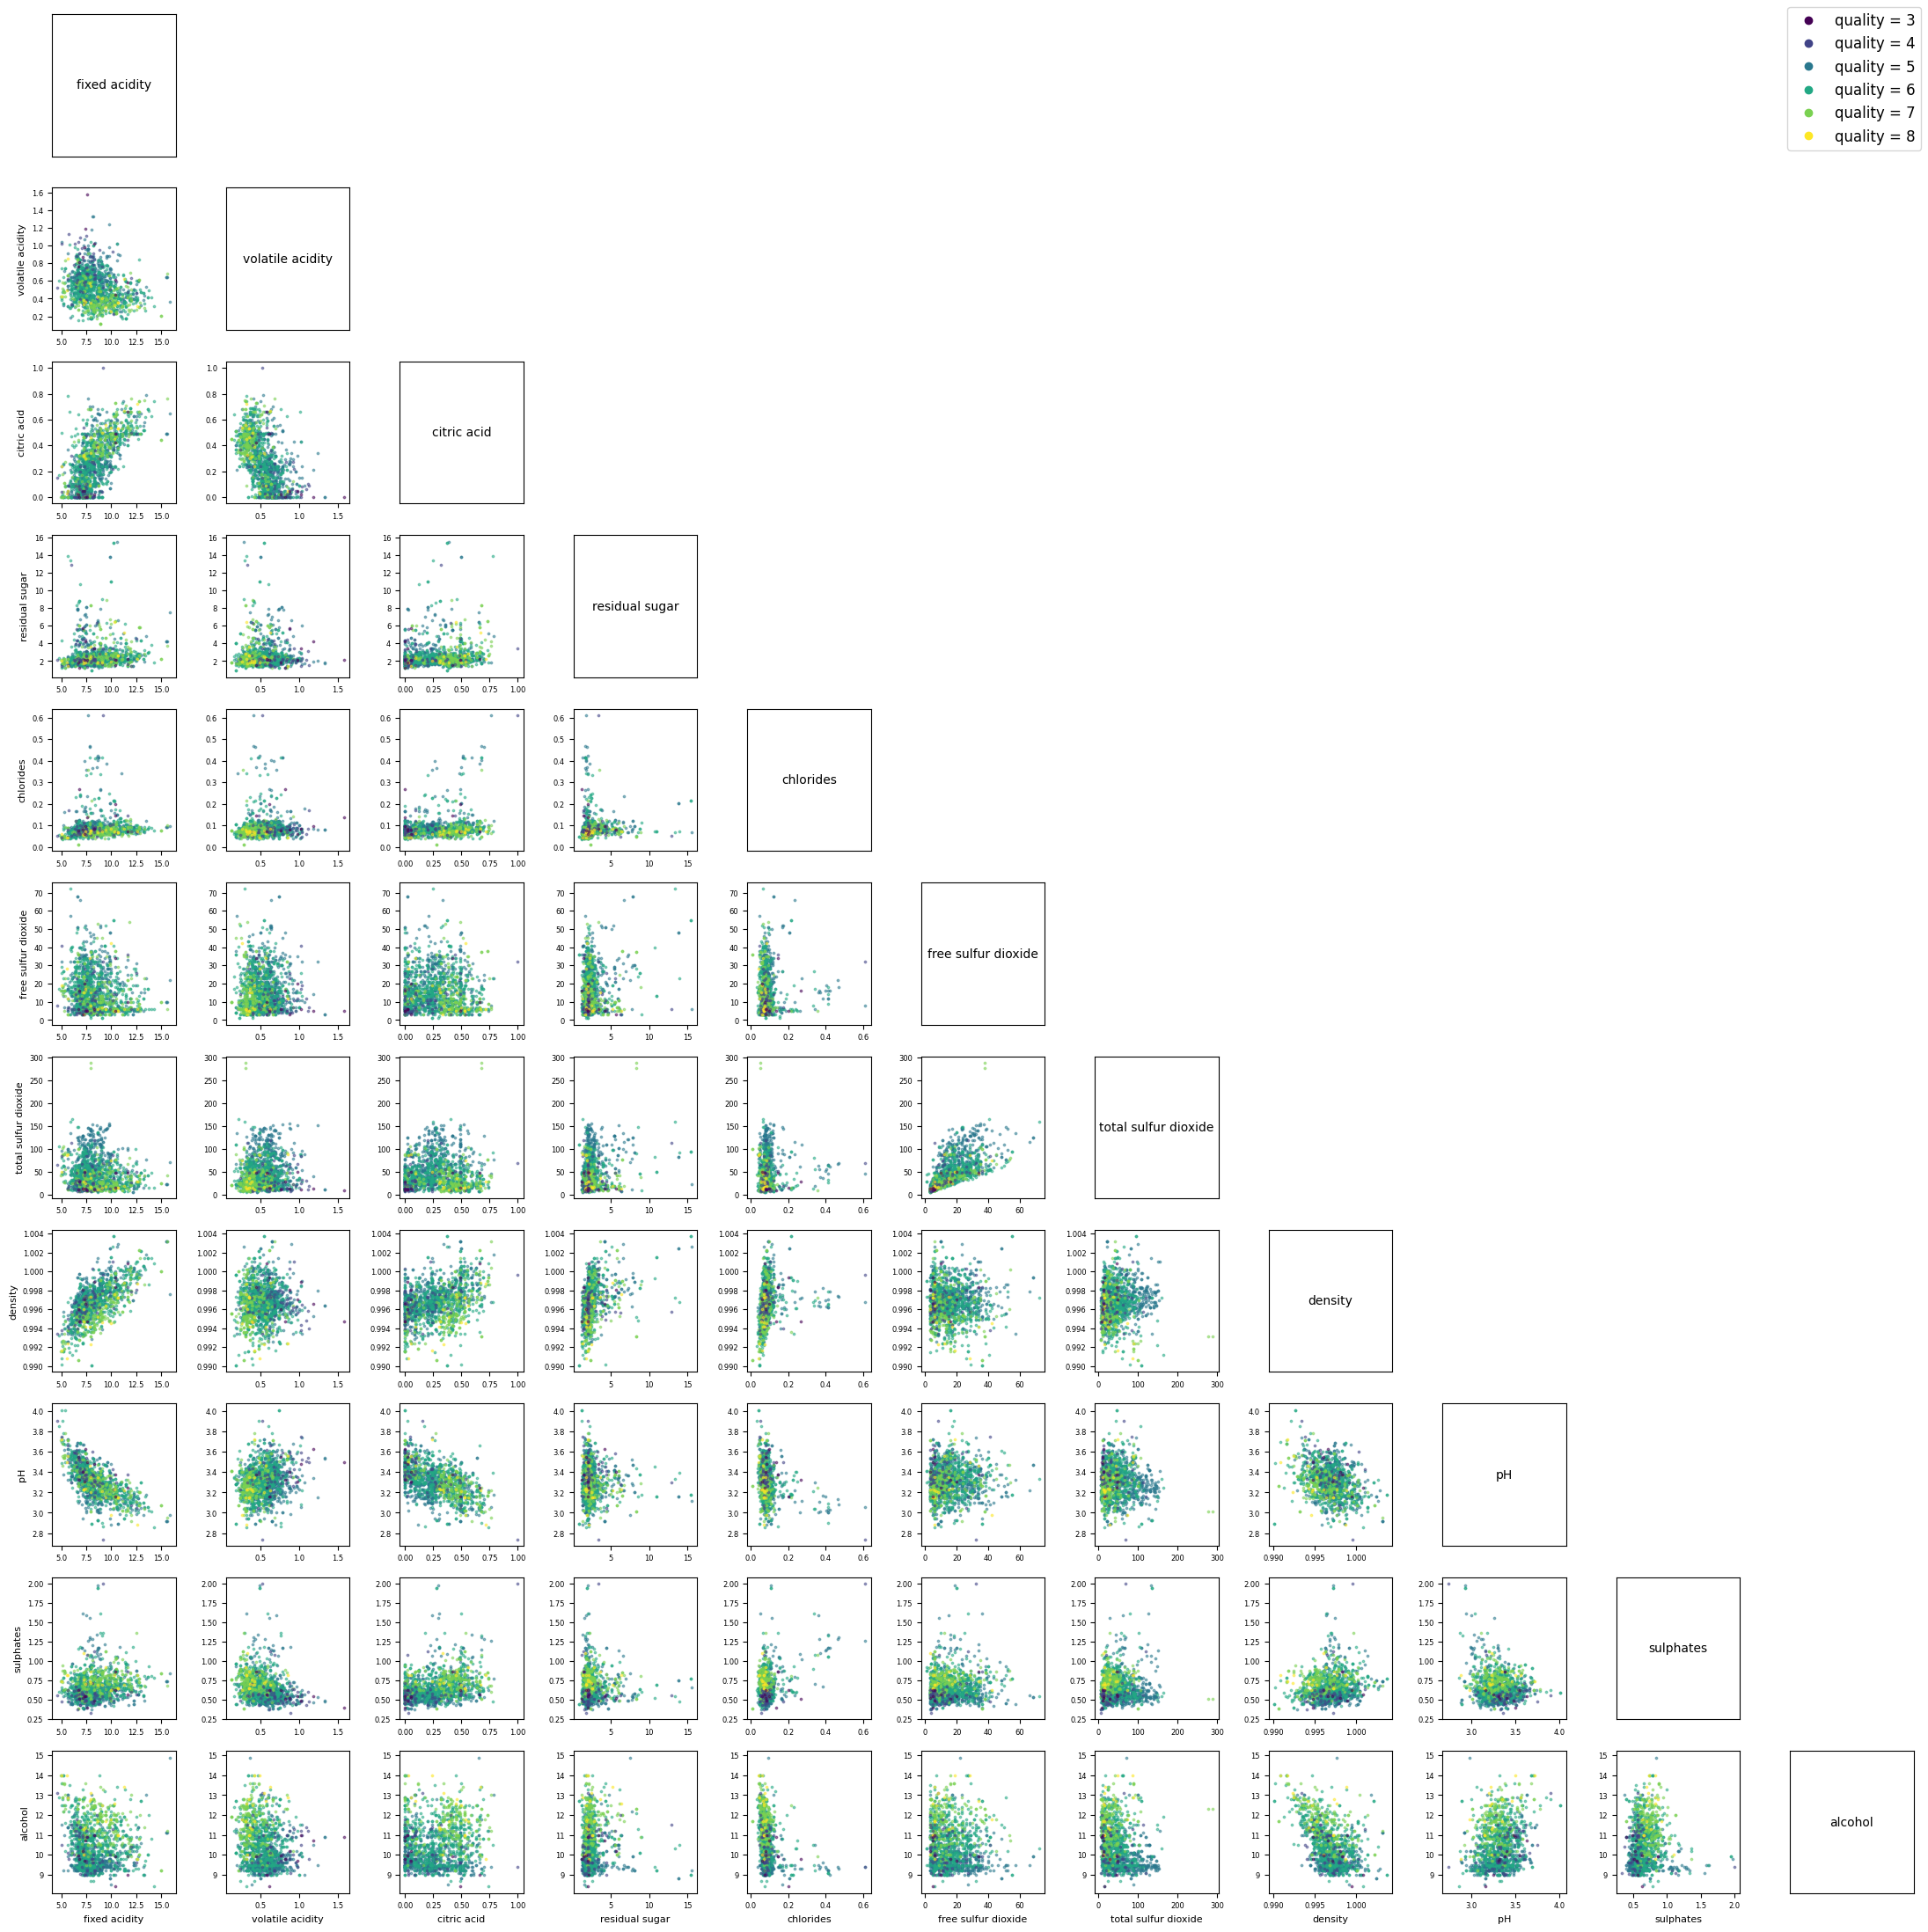

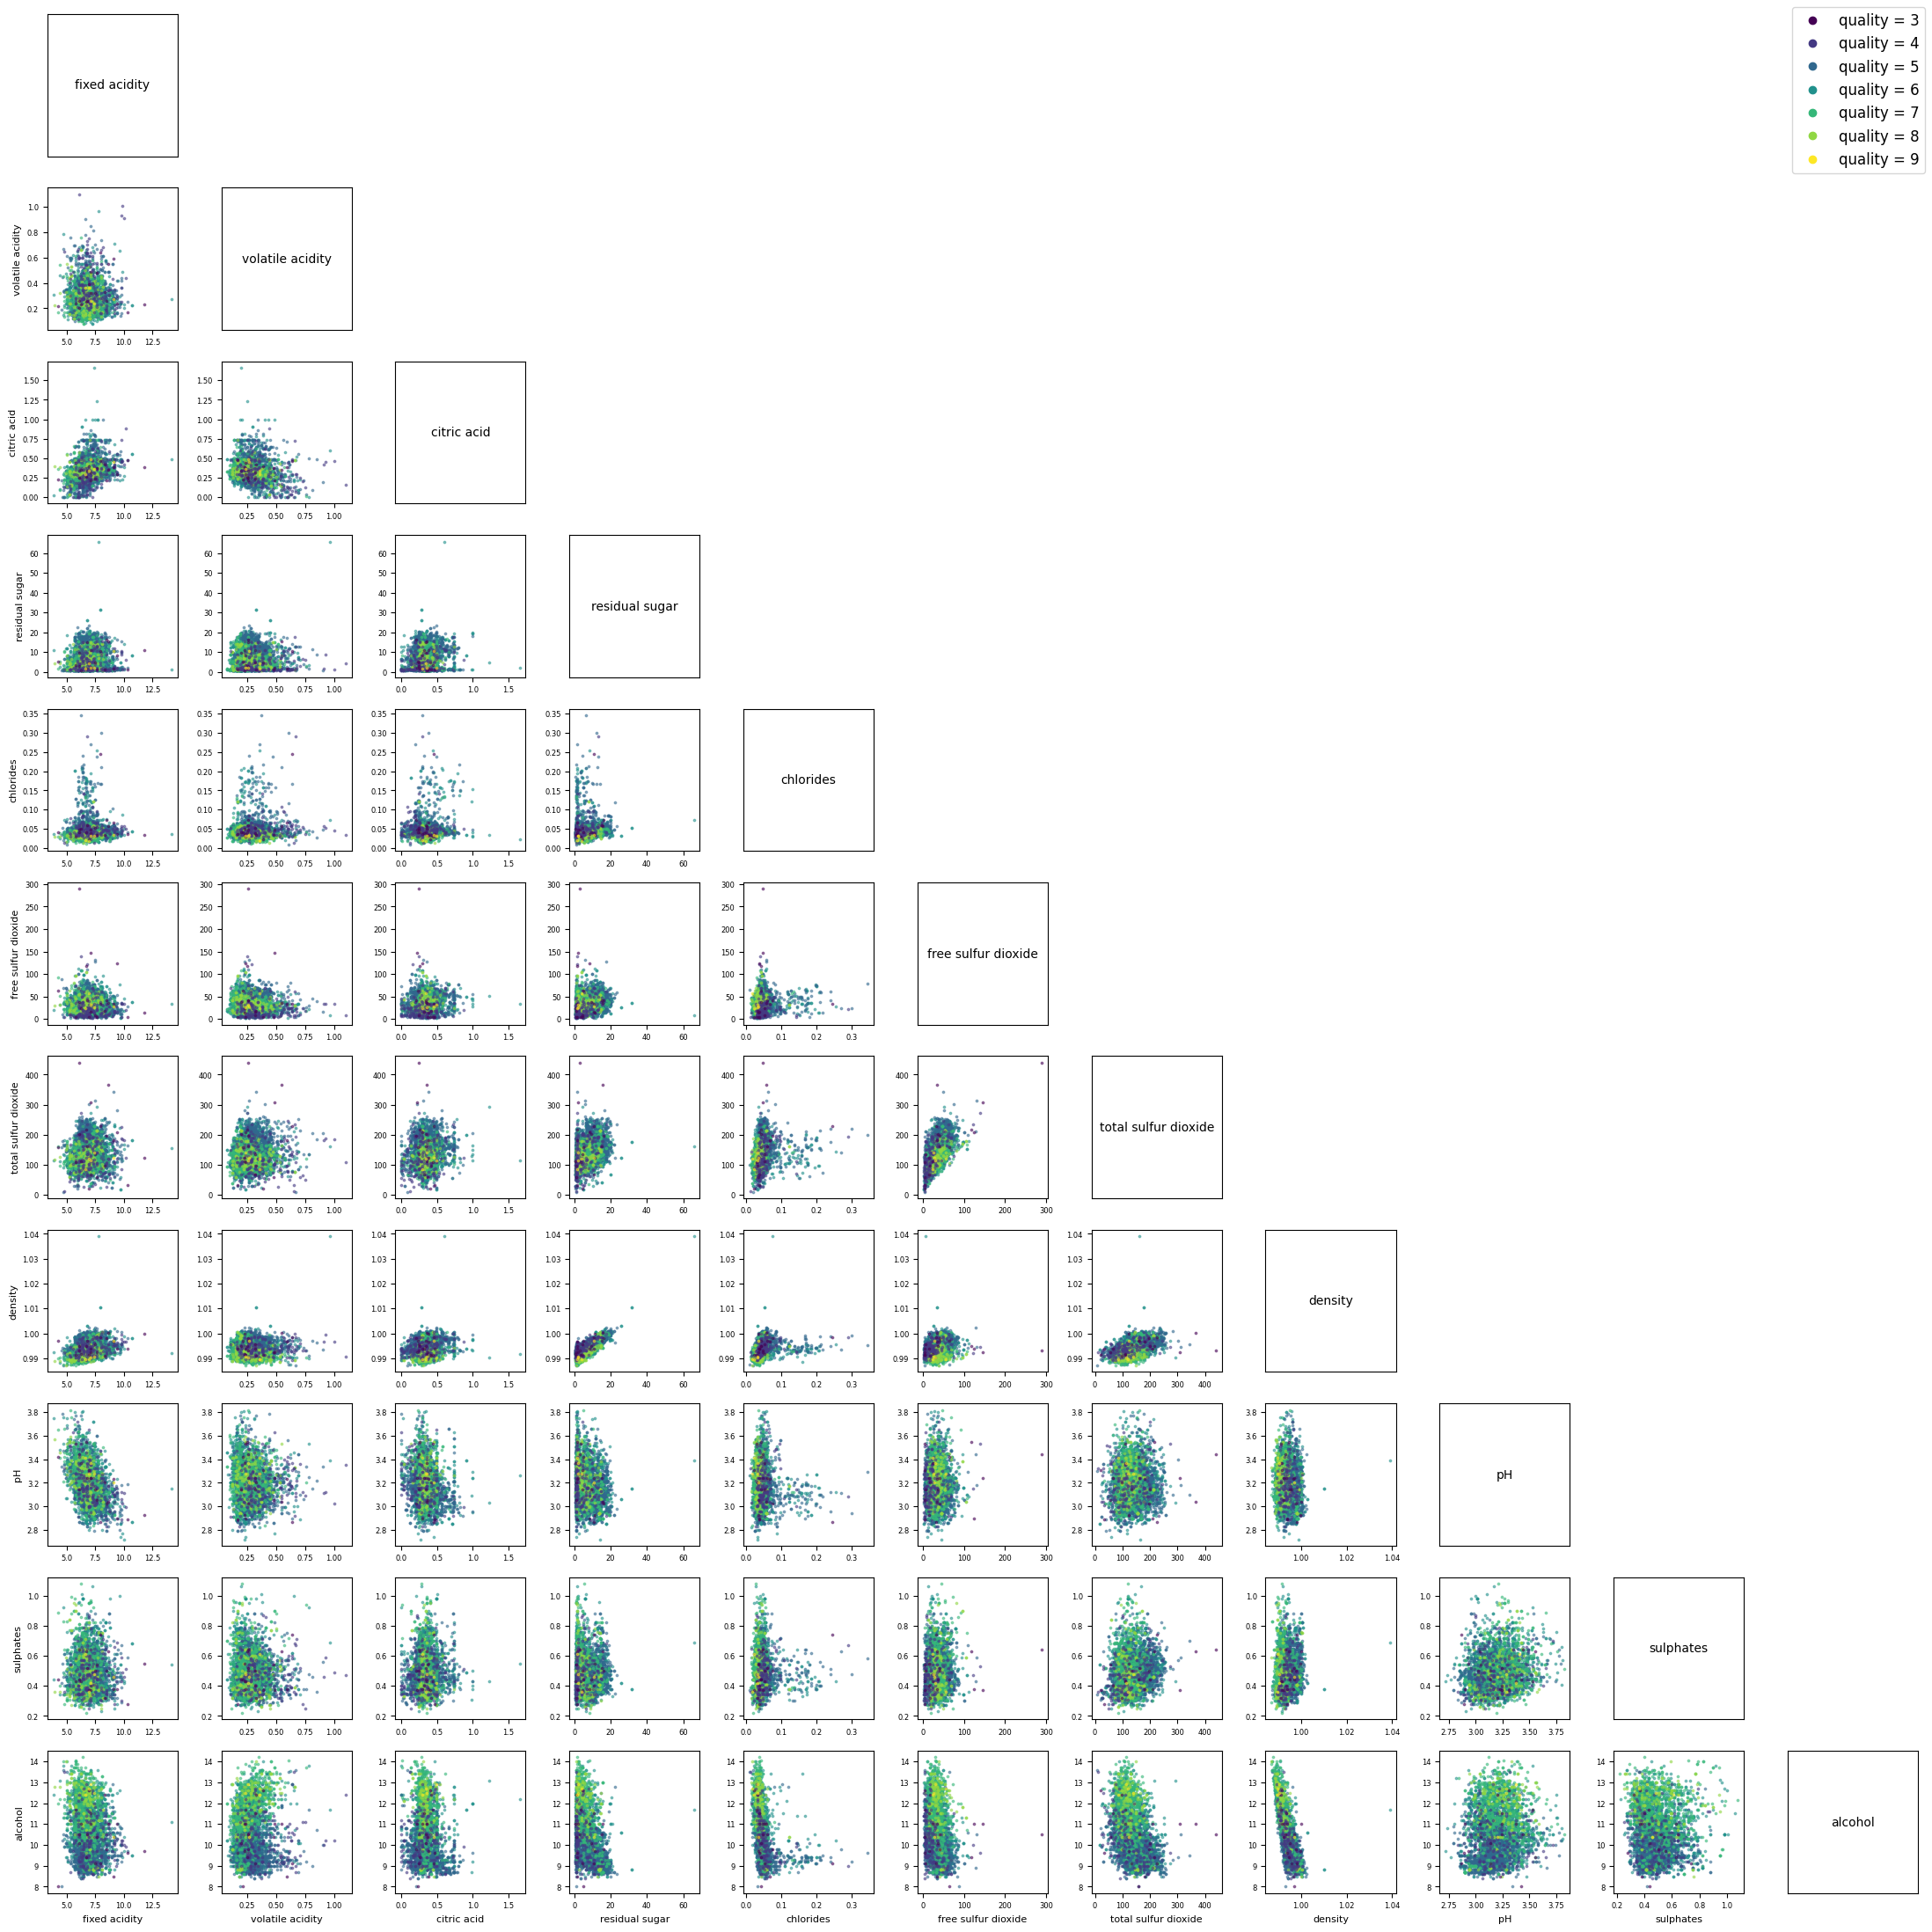

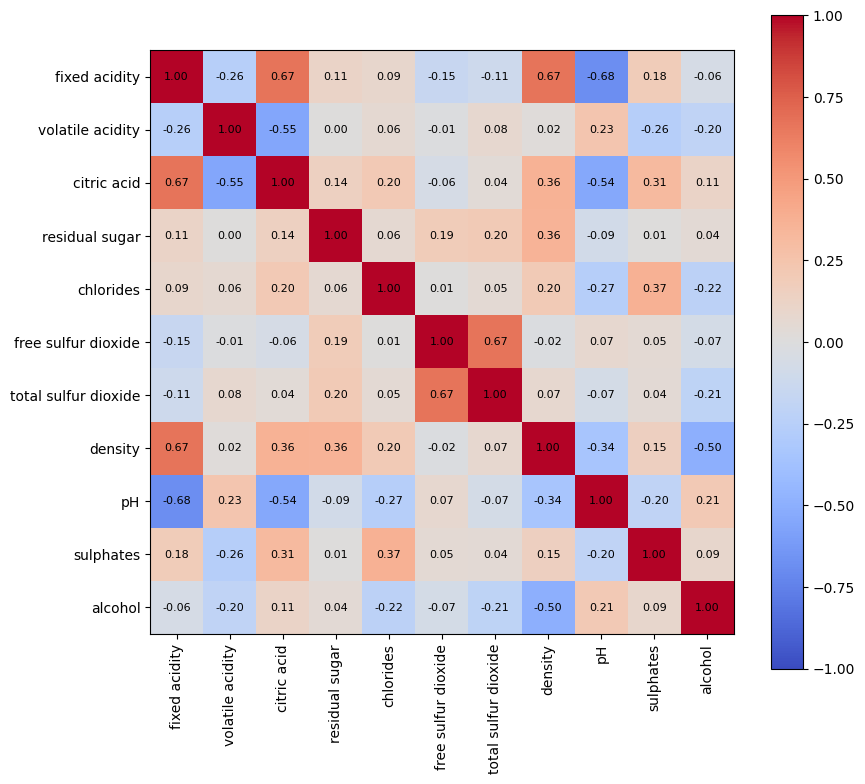

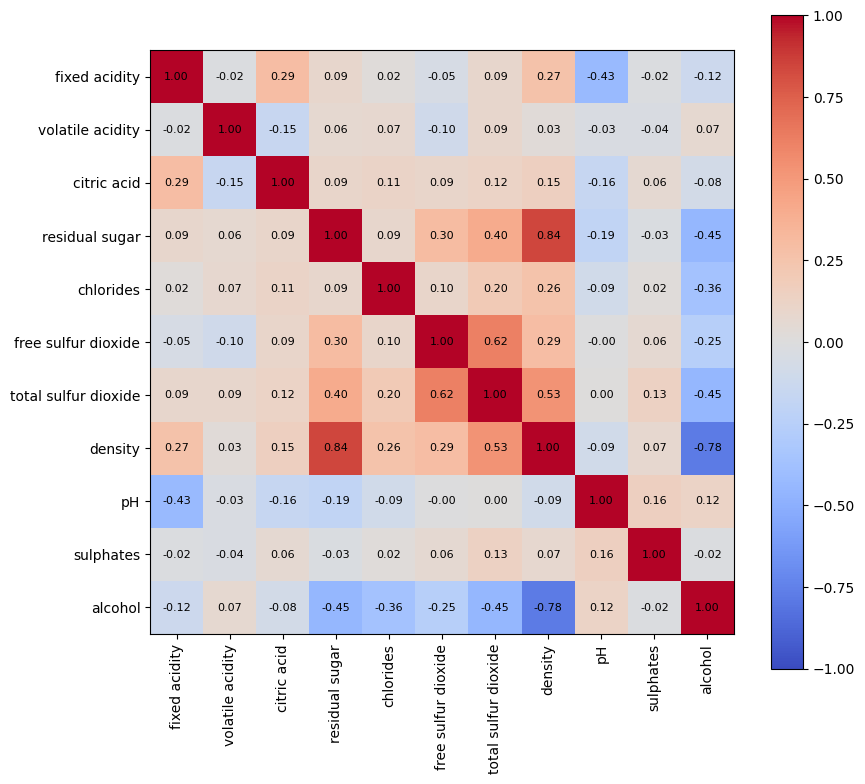

In [81]:
# Item 4

"""
A lógica do item 4 será a seguinte:
  1. Scatter plots entre todos os pares de preditores
  2. Calcular a matriz de correlação (Pearson) entre os preditores
  3. Mostrar a matriz de correlação como tabela e como imagem
"""

def scatterMatrix(dataframe):
  classes = getListaClasses(dataframe)
  D = len(preditores)

  cores = plt.cm.viridis(np.linspace(0, 1, len(classes)))
  cor_classe = dict(zip(classes, cores)) # Cada classe tem sempre a mesma cor

  # Classes mais frequentes são plotadas primeiro, para que as raras não fiquem escondidas
  ordem_plot = getDistClass(dataframe).index

  figs, axs = plt.subplots(nrows=D, ncols=D, figsize=(22, 22))

  for i, col_y in enumerate(preditores):
    for j, col_x in enumerate(preditores):

      if j > i: # Triângulo superior seria redundante (par já plotado)
        axs[i, j].axis('off')
        continue

      if i == j: # Diagonal: apenas o nome do preditor
        axs[i, j].text(0.5, 0.5, col_x, ha='center', va='center', fontsize=10)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        continue

      for classe in ordem_plot:
        subconjunto = dataframe[dataframe['quality'] == classe]
        axs[i, j].scatter(subconjunto[col_x], subconjunto[col_y], s=3,
                          color=cor_classe[classe], alpha=0.5)

      axs[i, j].tick_params(labelsize=6)
      if i == D - 1: # Rótulos do eixo x apenas na última linha
        axs[i, j].set_xlabel(col_x, fontsize=8)
      if j == 0: # Rótulos do eixo y apenas na primeira coluna
        axs[i, j].set_ylabel(col_y, fontsize=8)

  # Legenda das classes (ocupa o triângulo superior, que está vazio)
  legenda = [plt.Line2D([0], [0], marker='o', linestyle='', color=cor_classe[c],
                        label=f'quality = {c}') for c in classes]
  figs.legend(handles=legenda, loc='upper right', fontsize=12)

  plt.tight_layout() # Ajusta o layout para nada ficar "espremido"


def calcularCorrelacao(dataframe):
  return dataframe[preditores].corr() # Correlação de Pearson entre todos os pares


def heatmapCorrelacao(tabela):
  D = len(tabela)
  figs, ax = plt.subplots(figsize=(9, 8))

  imagem = ax.imshow(tabela, cmap='coolwarm', vmin=-1, vmax=1)
  ax.set_xticks(range(D))
  ax.set_xticklabels(tabela.columns, rotation=90)
  ax.set_yticks(range(D))
  ax.set_yticklabels(tabela.index)

  for i in range(D):
    for j in range(D):
      ax.text(j, i, f'{tabela.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

  figs.colorbar(imagem)
  plt.tight_layout() # Ajusta o layout para nada ficar "espremido"


# 4.1 - Scatter plots

scatterMatrix(df_red)

scatterMatrix(df_white)

# 4.2 - Matriz de correlação

corr_red = calcularCorrelacao(df_red)
corr_red

heatmapCorrelacao(corr_red)

corr_white = calcularCorrelacao(df_white)
corr_white

heatmapCorrelacao(corr_white)

# Existem relações relevantes entre alguns pares de preditores,
# embora a maioria tenha correlação fraca. No vinho tinto,
# destacam-se fixed acidity com citric acid (ρ = [X]), density (ρ = [X])
# e pH (ρ = [−X]), além de free e total sulfur dioxide (ρ = [X]).
# No vinho branco, destacam-se residual sugar com density (ρ = [X])
# e density com alcohol (ρ = [−X]). Nos scatter plots,
# esses pares formam nuvens alongadas em torno de uma reta,
# indicando relações aproximadamente lineares. Há também outliers,
# sobretudo no vinho branco, que podem distorcer o ρ de Pearson.
# A sobreposição das cores mostra que nenhum par separa as classes,
# e a redundância entre preditores correlacionados motiva o uso do PCA.

In [ ]:
# Item 5

"""
A lógica do item 5 é a seguinte:
    1. Carregar e combinar os dados do vinho tinto e do vinho branco
    2. Criar lista das características importantes para a análise
    3. Padronizamos os dados
    4. Calculamos a matriz de covariância
    5. Calculamos e ordenamos os autovetores e autovalores
    6. Calculamos a variância explicada
    7. Selecionamos as duas componentes principais
    8. Projetamos as observações no espaço das duas primeiras componentes
    9. Calculamos os loadings de PC1 e PC2
    10. Calculamos as médias de PC1 e PC2 em cada classe
"""
# 5.1 - Carregamento e preparação de dados

red = pd.read_csv("/content/winequality-red.csv", sep=";")
white = pd.read_csv("/content/winequality-white.csv", sep=";")

# Criamos váriaveis de classe para o vinho tinto e o vinho branco.
red["class"] = "red"
white["class"] = "white"

# Juntamos os dois DataFrames do vinho tinto e do vinho branco em um único dataframe.
data = pd.concat([red, white], ignore_index=True)

# 5.2 - Seleção de varíaveis utilizadas na PCA

# Aqui criamos uma lista das características númericas do vinho que serão utilizadas na análise de PCA.
# A característica "class" não será utilizada na PCA, pois representa a classe do vinho e será usada posteriormente para diferenciar red e white.
# Enquanto isso, a característica "quality" não será utilizada, pois não faz parte das 11 características fisico-quimicas selecionadas para a análise.
features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

# Extraimos os valores para uma matriz NumPy, que será utilizada nas operações matemáticas do PCA.
X = data[features].to_numpy()

# 5.3 - Padronização dos Dados

mu = np.mean(X, axis=0) # Calcula a média de cada coluna da matriz X.
sigma = np.std(X, axis=0, ddof=1) # Calcula o desvio padrão de cada coluna da matriz X, com ddof=1 indicando o uso do desvio padrão amostral.

# Padronização: Z = (X - μ)/ σ
Z = (X - mu) / sigma

# 5.4 - Cálculo da matriz de covariância

# Obtém o número de observações na matriz Z.
n = Z.shape[0]

# Transpõe a matriz Z, multiplica Z.T por Z e divide por (n - 1), calculando a matriz de covariância amostral.
C = (Z.T @ Z) / (n - 1)

# 5.5 - Cálculo e ordenação dos auvalores e autovetores

# eigh é utilizado para matrizes simétricas e retorna os autovalores e os autovetores ordenados em ordem crescente dos autovalores.
eigenvalues, eigenvectors = np.linalg.eigh(C) # Retorna os autovalores e autovetores da matriz de covariância C.

idx = np.argsort(eigenvalues)[::-1] # Vamos ordenar em ordem do maior para o menor. [::-1] inverte a ordem crescente retornada por np.argsort.

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 5.6 - Cálculo da variância explicada

explained_variance = eigenvalues / np.sum(eigenvalues)

print("Proporção de variância explicada das duas primeiras componentes:",
    explained_variance[:2])

print("Proporção de variancia explicada acumulada das duas primeiras componentes:",
    np.sum(explained_variance[:2]))

# 5.7 - Seleção das duas primeiras componentes PC1 e PC2

# Guarda os dois primeiros autovetores em uma matriz W, sendo eles PC1 e PC2.
W = eigenvectors[:, :2]

Y = Z @ W # Projeta as 6497 observações no espaço formado pelas duas primeiras componentes principais, representando cada vinho por duas coordenadas.

# 5.8 - Projeção e visualização das observações

# As classes não participam na formação do cálculo do PCA.
# Elas são utilizadas somente após a projeção para identificar visualmente os grupos red e white.

#Converte a coluna do DataFrame [class] em um array NumPy, para facilitar a manipulação dos dados.
classes = data["class"].to_numpy()

plt.figure(figsize=(10, 7))

for classe in ["red", "white"]:
    mask = classes == classe # Formamos uma máscara booleana indicando quais observações pertencem à classe que está sendo analisada.

    # Usamos a função scatter para colocar os pontos no gráfico do PCA.
    plt.scatter(
        # [mask, 0] seleciona as coordenadas em PC1 da classe atual e [mask, 1] seleciona as coordenadas em PC2.
        Y[mask, 0],
        Y[mask, 1],
        s=10, # Define o tamanho dos pontos.
        alpha=0.4, # Define a transparência dos pontos.
        label=classe # Define qual nome deve ser associado a cada conjunto de pontos.
    )

plt.xlabel("PC1") # Define o eixo horizontal.
plt.ylabel("PC2") # Define o eixo vertical.
plt.title("PCA - Wine Quality")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout() # tight_layout impede a sobrepossição de elementos.
plt.show()

# 5.9 - Cálculo e análise de loadings

# Cria uma tabela chamada loadings com as duas primeiras componentes principais
loadings = pd.DataFrame( # Os loadings indicam as contribuições de cada variável original para PC1 e PC2.
    eigenvectors[:, :2],
    index=features,
    columns=["PC1", "PC2"]
)

print("Loadings:\n", loadings)

# 5.10 - Cálculo das componentes de classe

# Cria uma tabela com as coordenadas de cada vinho em PC1 e PC2 e sua respectiva classe, facilitando a análise de grupos.
result = pd.DataFrame({
    "PC1": Y[:, 0],
    "PC2": Y[:, 1],
    "class": data["class"].to_numpy()
})

# Agrupa as observações por classe e calcula a média das coordenadas PCA para cada classe.
print(result.groupby("class")[["PC1", "PC2"]].mean())